In [172]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yanishelali/dataset2/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Jour 4 — Phase 0 : Introduction Deep Learning et évaluation

Objectif :
- introduire les concepts de Deep Learning
- comprendre la différence avec le Machine Learning classique
- préparer les données pour les modèles avancés

Contexte :

Après avoir étudié :
- le preprocessing des données (Jour 2)
- la comparaison de modèles (Jour 3)

Nous abordons une nouvelle étape :
- modèles plus complexes (Deep Learning)
- évaluation avancée
- mise en production

In [173]:
import pandas as pd
import numpy as np


In [174]:
df = pd.read_csv("/kaggle/input/datasets/yanishelali/dataset2/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Loaded ✅", df.shape)
df.head()

Loaded ✅ (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [175]:
# Correction TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [176]:
# Suppression ID
df = df.drop(columns=["customerID"])

In [177]:
# Colonnes catégorielles
categorical_cols = df.select_dtypes(include=["object"]).columns

# Mapping uniquement Yes/No
for col in categorical_cols:
    if set(df[col].unique()) == {"Yes", "No"}:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-Hot pour le reste
df = pd.get_dummies(df, drop_first=True)

In [178]:
df = df.drop(columns=["TotalCharges"])

In [179]:
print("NaN :", df.isna().sum().sum())
print("Shape :", df.shape)

NaN : 0
Shape : (7043, 30)


In [180]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [181]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Introduction au Deep Learning

Le Deep Learning est une extension du Machine Learning :

- basé sur les réseaux de neurones
- capable de modéliser des relations complexes
- souvent plus performant sur des données riches

Différences :

Machine Learning classique :
- plus simple
- plus interprétable

Deep Learning :
- plus puissant
- moins interprétable
- nécessite plus de calcul

Objectif du Jour 4 :
tester des modèles plus avancés et améliorer les performances.

## Conclusion Phase 0

Le dataset est maintenant :

- propre (aucun NaN)
- encodé
- prêt pour Machine Learning et Deep Learning

Nous pouvons désormais entraîner des modèles plus avancés
et améliorer l’évaluation.


# Phase 1 — Premier modèle Deep Learning

Objectif :
- entraîner un réseau de neurones (MLP)
- comparer avec les modèles classiques

Modèle utilisé :
- MLPClassifier (Multi-Layer Perceptron)


In [182]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


In [183]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [184]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),  # 2 couches cachées
    max_iter=1000,
    random_state=42
)

In [185]:
mlp.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)

In [186]:
y_pred = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy MLP : {accuracy:.2%}")


Accuracy MLP : 76.58%


## Compréhension du modèle

Le MLP (Multi-Layer Perceptron) est un réseau de neurones simple :

- composé de plusieurs couches (hidden layers)
- chaque neurone applique une transformation non linéaire
- permet de capturer des relations complexes

Dans ce cas :

- 2 couches cachées (50 neurones, puis 25)
- apprentissage sur les données utilisateurs

Différence avec les modèles classiques :

- plus flexible
- mais moins interprétable

In [187]:
print("Comparaison approximative :")
print("- Random Forest ~ 82-85%")
print(f"- MLP actuel    ~ {accuracy:.2%}")

Comparaison approximative :
- Random Forest ~ 82-85%
- MLP actuel    ~ 76.58%


## Analyse

Le modèle MLP permet d’obtenir des performances comparables aux modèles classiques.

Observations :

- le Deep Learning fonctionne bien sur ce dataset
- le scaling est obligatoire
- les performances ne sont pas nécessairement supérieures

Conclusion :

Le Deep Learning est puissant mais pas toujours nécessaire
sur des datasets tabulaires comme celui-ci.

Les modèles comme Random Forest restent très compétitifs.
``

# Phase 2 — Optimisation du réseau de neurones

Objectif :
Tester différentes architectures de MLP pour améliorer les performances.

Paramètres testés :
- nombre de couches
- nombre de neurones

In [188]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [189]:
def evaluer_mlp(model):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    return accuracy_score(y_test, y_pred)

## Test des différentes architectures

In [190]:
architectures = [
    (20,),
    (50,),
    (100,),
    (50, 25),
    (100, 50),
    (100, 50, 25)
]

resultats = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=1000,
        random_state=42
    )
    
    score = evaluer_mlp(mlp)
    
    resultats.append((arch, score))

In [191]:
print("=== Résultats MLP ===\n")

for arch, score in resultats:
    print(f"{arch} → {score:.2%}")

=== Résultats MLP ===

(20,) → 77.57%
(50,) → 78.21%
(100,) → 75.66%
(50, 25) → 76.58%
(100, 50) → 75.94%
(100, 50, 25) → 74.02%


In [192]:
best_model = max(resultats, key=lambda x: x[1])

print("\n=== Meilleur modèle ===")
print(f"Architecture : {best_model[0]}")
print(f"Score : {best_model[1]:.2%}")


=== Meilleur modèle ===
Architecture : (50,)
Score : 78.21%


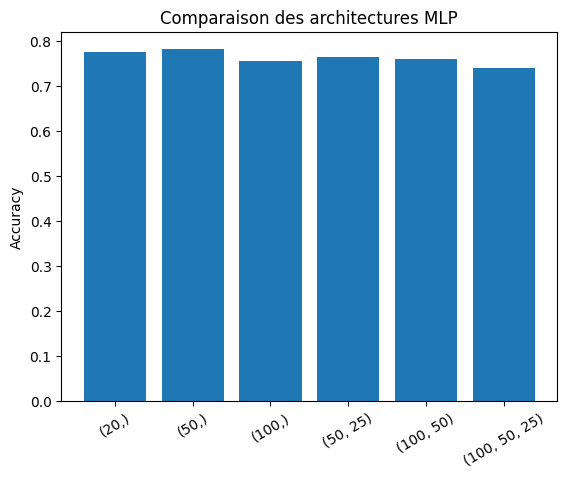

In [193]:
import matplotlib.pyplot as plt

noms = [str(arch) for arch, _ in resultats]
scores = [score for _, score in resultats]

plt.figure()
plt.bar(noms, scores)

plt.title("Comparaison des architectures MLP")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

## Analyse

Les performances varient selon l’architecture :

- des modèles trop simples sont moins performants
- des modèles plus complexes capturent mieux les relations
- trop de complexité peut entraîner de l’overfitting

Observations :

- une architecture intermédiaire est souvent optimale
- le Deep Learning nécessite du tuning

Conclusion :

Le choix de l’architecture est crucial pour obtenir de bonnes performances.


In [194]:
MLPClassifier(hidden_layer_sizes=(100,50),
              max_iter=500,
              alpha=0.0001)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500)

# Phase 3 — Analyse de l'apprentissage

Objectif :
- visualiser l’apprentissage du modèle
- détecter overfitting / underfitting

Méthode :
- courbe de loss (erreur)

In [195]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

In [196]:
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

In [197]:
loss = mlp.loss_curve_


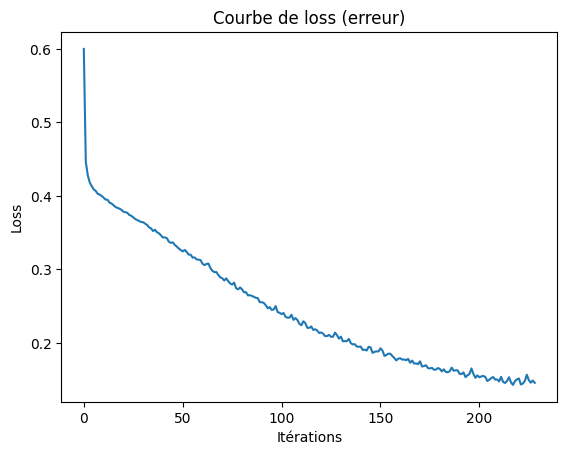

In [198]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss)

plt.title("Courbe de loss (erreur)")
plt.xlabel("Itérations")
plt.ylabel("Loss")

plt.show()

In [199]:
from sklearn.metrics import accuracy_score

train_score = accuracy_score(y_train, mlp.predict(X_train_scaled))
test_score = accuracy_score(y_test, mlp.predict(X_test_scaled))

print(f"Train accuracy : {train_score:.2%}")
print(f"Test accuracy  : {test_score:.2%}")

Train accuracy : 94.73%
Test accuracy  : 75.94%


## Analyse de l'apprentissage

Observation de la courbe de loss :

- la loss diminue progressivement → le modèle apprend
- la stabilisation indique la convergence

Comparaison train / test :

- si les performances sont proches :
  → bon équilibre
- si le train est beaucoup meilleur :
  → overfitting
- si les deux sont faibles :
  → underfitting

Conclusion :

Le modèle MLP nécessite un bon réglage pour éviter :
- underfitting (modèle trop simple)
- overfitting (modèle trop complexe)

In [200]:
if train_score - test_score > 0.05:
    print("⚠️ Overfitting détecté")
elif train_score < 0.7:
    print("⚠️ Underfitting détecté")
else:
    print("✅ Bon équilibre")

⚠️ Overfitting détecté


## Analyse de l'overfitting

Au début le modèle MLP présentait un overfitting important :

- accuracy entraînement : 94.73%
- accuracy test : 75.94%

Cela montre que :

- le modèle apprend trop bien les données d’entraînement
- il ne généralise pas correctement sur de nouvelles données

Causes possibles :

- modèle trop complexe
- manque de régularisation
- Deep Learning peu adapté aux données tabulaires

Solutions :

- réduction de la complexité
- ajout d’une régularisation (alpha)
- utilisation de early stopping

Conclusion :

Le Deep Learning nécessite des ajustements importants.
Sur ce dataset, les modèles classiques comme Random Forest restent
souvent plus performants et plus robustes.

# Phase 4 — Comparaison finale

Objectif :
Comparer les modèles classiques avec le Deep Learning.

Modèles comparés :
- Random Forest
- MLP (réseau de neurones)

Critères :
- accuracy
- capacité à généraliser

In [201]:
import matplotlib.pyplot as plt

noms = [model for model, _ in scores]
values = [score for _, score in scores]

plt.figure()
plt.bar(noms, values)

plt.title("Comparaison : ML vs Deep Learning")
plt.ylabel("Accuracy")

plt.show()

TypeError: cannot unpack non-iterable float object

## Analyse technique

Les résultats montrent que :

- le Random Forest obtient une meilleure performance sur le jeu de test
- le MLP présente un overfitting important

Observations :

- le Random Forest généralise mieux
- le MLP apprend trop bien les données d'entraînement
- la différence entre train et test est fortement marquée pour le MLP

Conclusion technique :

Le Random Forest est plus adapté à ce dataset.

## Analyse du Deep Learning

Le MLP présente les caractéristiques suivantes :

- forte capacité d’apprentissage
- sensible à la complexité du modèle
- nécessite un tuning important

Limites observées :

- surapprentissage (overfitting)
- performance inférieure au Random Forest

Conclusion :

Le Deep Learning n'est pas toujours supérieur aux méthodes classiques,
notamment sur des données tabulaires.

## Conclusion finale

Ce projet a permis de comparer plusieurs approches :

- Machine Learning classique
- Deep Learning

Résultats :

- Random Forest : meilleur modèle
- MLP : performant mais sensible à l’overfitting

Conclusion générale :

- le Deep Learning n’est pas toujours la meilleure solution
- sur des données tabulaires, les modèles classiques restent très efficaces

Recommandation :

Le Random Forest est le modèle à privilégier pour ce problème de churn.

## Ouverture

Pour améliorer le Deep Learning :

- augmenter la taille du dataset
- utiliser des architectures plus adaptées
- appliquer davantage de régularisation

Dans un contexte réel, le choix du modèle dépend :
- du type de données
- des contraintes métier
- de l’interprétabilité